In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [77]:
metrics_dir=os.path.join(os.getcwd(),"metrics")
# --- LOAD THE .pkl FILE GENERATED PREVIOUSLY ---
adapt=2
test_ds_b4=False
if test_ds_b4:
    identifier=f"testing_dsb4_adaptable{adapt}" if adapt > 0 else "testing_dsb4"
else:
    identifier=f"30000_1000_100_adaptable{adapt}" if adapt > 0 else "30000_1000_100"
    # identifier="1000_200_median"


In [78]:
filename= f"channel_metrics_by_network_{identifier}_3.csv"
results_df= pd.read_csv(os.path.join(metrics_dir, filename))
print(f"Results loaded from {os.path.join(metrics_dir, filename)}")
print(results_df.head())


Results loaded from c:\Users\Pc\Documents\Tese\LAVA_SNN_ripples\snnTorch\eval\live_results\metrics\channel_metrics_by_network_30000_1000_100_adaptable2_3.csv
                   Network                     Dataset   TP   FP  FN  \
0  dsb4updn_median_200_15f  Amigo2_2019-07-11_11-57-07  166  171  58   
1  dsb4updn_median_200_15f    Dlx1_2021-02-12_12-46-54   27   31   4   
2  dsb4updn_median_200_15f    Som2_2019-07-24_12-01-49   50   30  14   
3  dsb4updn_median_200_15f    Thy7_2020-11-11_16-05-00   99   18  40   
4  dsb4updn_median_200_11b  Amigo2_2019-07-11_11-57-07  165  158  59   

   Precision    Recall        F1  
0   0.492582  0.741071  0.591800  
1   0.465517  0.870968  0.606742  
2   0.625000  0.781250  0.694444  
3   0.846154  0.712230  0.773437  
4   0.510836  0.736607  0.603291  


In [79]:
dataset_colors={
   "Amigo": "#8E44AD",
   "Dlx": "#E74C3C",
   "Som": "#FFC300",
   "Thy": "#17BECF"
}

In [80]:
def plot_whiskers_by_dataset(df, metrics=["Precision", "Recall", "F1"], colors=None,back_colors=None,add_overall=True):
    if colors is None:
        colors = {
            "Precision": "royalblue",
            "Recall": "seagreen",
            "F1": "darkorange"
        }
    labels=["Amigo","Dlx","Som","Thy","Overall"]
    df = df.copy()  # avoid modifying original DataFrame

    # Compute and add "Overall" if requested
    if add_overall:
        overall_rows = df[metrics].copy()
        overall_rows["Dataset"] = "Overall"
        df = pd.concat([df, overall_rows], ignore_index=True)

    # Get dataset list and ensure "Overall" is last
    datasets = sorted(df['Dataset'].unique())
    if "Overall" in datasets:
        datasets = [d for d in datasets if d != "Overall"] + ["Overall"]

    width = 1  # Width of each box
    fig, ax = plt.subplots(figsize=(10, 6))

    positions = []
    data = []
    plot_colors = []
    xticks = []
    xtick_labels = []

    for i, dataset in enumerate(datasets):
        base_pos = i * (len(metrics) + 1)  # spacing between groups
        for j, metric in enumerate(metrics):
            vals = df[df['Dataset'] == dataset][metric].dropna().values
            pos = base_pos + j * width
            data.append(vals)
            positions.append(pos)
            plot_colors.append(colors.get(metric, "gray"))

        # X-axis ticks centered on group
        xticks.append(base_pos + (len(metrics) - 1) * width / 2)
        xtick_labels.append(labels[i])

        # Background shading
        if back_colors and labels[i] in back_colors:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color=back_colors[labels[i]], alpha=0.2)
        else:
            ax.axvspan(base_pos - 0.7, base_pos + len(metrics) * width - 0.3, color="lightgray", alpha=0.2)

    # Draw boxplots
    for d, p, c in zip(data, positions, plot_colors):
        bplot = ax.boxplot(d, positions=[p], widths=width, patch_artist=True,
                           showfliers=False, medianprops=dict(color='black'))
        for patch in bplot['boxes']:
            patch.set_facecolor(c)

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=14)
    ax.set_ylabel("Score", fontsize=14)
    ax.set_title("Precision, Recall, and F1 Score - Min 3 Channels", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(-1, len(datasets) * (len(metrics) + 1) - 1)
    ax.set_ylim(0, 1)  # Assuming scores are between 0 and 1

    # Clean up
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # Legend
    # legend_handles = [Patch(facecolor=colors[m], label=m) for m in metrics]
    # ax.legend(handles=legend_handles, fontsize=12, loc='upper left', bbox_to_anchor=(1.01, 0.5))

    plt.tight_layout()
    plt.show()
    return fig, ax

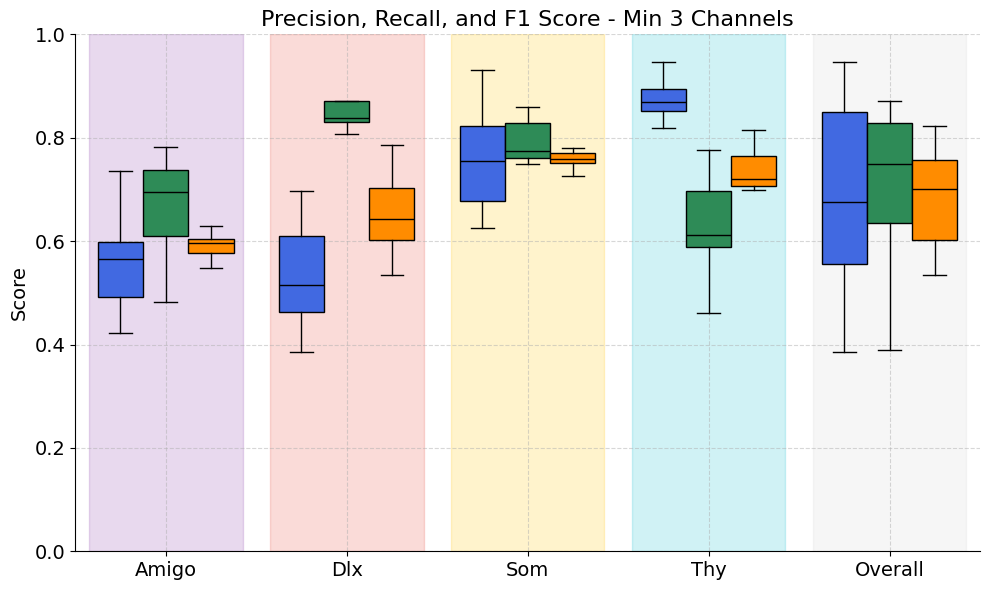

In [81]:
fig,ax=plot_whiskers_by_dataset(results_df,back_colors=dataset_colors)
# Channel-wise, by dataset
# fig.savefig(os.path.join("figures", f"channel_metrics_by_network_{identifier}_3.png"), bbox_inches='tight', dpi=300)

In [82]:
import pandas as pd

def summarize_metrics_by_dataset_and_network(df, metrics=["Precision", "Recall", "F1"]):
    summary_rows = []

    datasets = sorted(df['Dataset'].unique())

    # Summarize per dataset
    for dataset in datasets:
        subset = df[df['Dataset'] == dataset][metrics]
        row = {"Dataset": dataset}
        for metric in metrics:
            vals = subset[metric].dropna()
            row[f"{metric} Median ± Std"] = f"{vals.median():.2f} ± {vals.std():.2f}"
            row[f"{metric} Mean"] = f"{vals.mean():.2f}"
            row[f"{metric} Peak"] = f"{vals.max():.2f}"
        summary_rows.append(row)

    # Compute mean metrics per network across datasets
    # Assuming df has a 'Network' column
    network_means = df.groupby('Network')[metrics].mean()

    overall_row = {"Dataset": "Overall"}

    for metric in metrics:
        all_vals = df[metric].dropna()
        mean = all_vals.mean()
        std = all_vals.std()
        median = all_vals.median()

        # Find network with best average metric across datasets
        best_network = network_means[metric].idxmax()
        best_network_avg = network_means.loc[best_network, metric]

        overall_row[f"{metric} Median ± Std"] = f"{median:.2f} ± {std:.2f}"
        overall_row[f"{metric} Mean"] = f"{mean:.2f}"
        overall_row[f"{metric} Peak"] = f"{best_network_avg:.2f}"

    summary_rows.append(overall_row)

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


In [83]:
summary_df=summarize_metrics_by_dataset_and_network(results_df, metrics=["Precision", "Recall", "F1"])
summary_df.to_excel(os.path.join("figures", f"summary_channel_wide_{identifier}_3.xlsx"), index=False)

In [84]:
def plot_precision_recall_by_dataset(df):

    # Define consistent colors and labels per dataset
    list_datasets=sorted(df["Dataset"].unique())
    dataset_labels = {
        list_datasets[0]: "Amigo",
        list_datasets[1]: "Dlx",
        list_datasets[2]: "Som",
        list_datasets[3]: "Thy"
    }
    dataset_colors = {
        "Amigo": "#E69F00",  # orange
        "Dlx": "#56B4E9",    # sky blue
        "Som": "#009E73",    # teal
        "Thy": "#F0E442",    # yellow
    }
   

    plt.figure(figsize=(8, 6))

    # Plot each dataset group
    for dataset in sorted(df["Dataset"].unique()):
        group = df[df["Dataset"] == dataset]
        label=dataset_labels.get(dataset, dataset)
        color=dataset_colors.get(label, "gray")
        plt.scatter(
            group["Recall"], group["Precision"],
            label=label,color=color,
            alpha=0.8,
            s=60,
            edgecolors='black'
        )

    # Aesthetics
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel("Recall", fontsize=12)
    plt.ylabel("Precision", fontsize=12)
    plt.title("Precision vs. Recall by Dataset", fontsize=14)
    plt.legend(title="Dataset", title_fontsize=13, fontsize=12, loc='center left',bbox_to_anchor=(1.01, 0.5))
    plt.grid(True, linestyle='--', alpha=0.6)

    # Optional: remove top/right spines
    for spine in ['top', 'right']:
        plt.gca().spines[spine].set_visible(False)

    plt.tight_layout()
    plt.show()


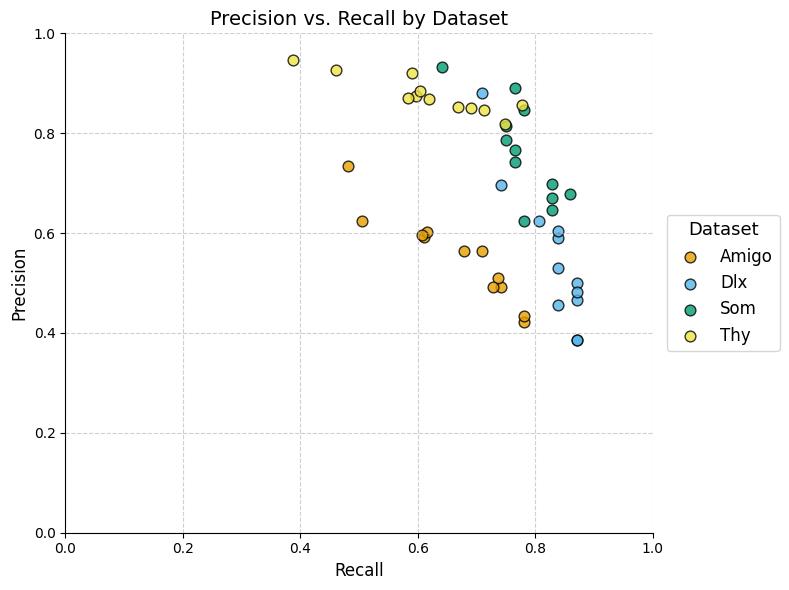

In [85]:
plot_precision_recall_by_dataset(results_df)